Libraries loaded.
Cases loaded for evaluation : 40
  Male   : 20
  Female : 20

=== Sample Case ===
  case_id       : 0
  gender        : male
  age           : 66
  original_prob : 0.9218
  cf_prob       : 0.2030
  output chars  : 2099
Evaluation dimensions defined:
  D1_medical_accuracy : Medical Accuracy
  D2_association_distinction : Association / Causation Distinction
  D3_actionability : Actionability of Recommendations
  D4_readability : Readability and Clarity
  D5_disclaimer_adequacy : Disclaimer Adequacy
  D6_insurance_relevance : Insurance / Risk Management Relevance
  D7_overall_quality : Overall Quality
Judge personas defined:
  · medical_expert
  · insurance_specialist
  · general_public
=== Test Run: Case 0 × medical_expert ===

Scores:
  Medical Accuracy                              : 5
  Association / Causation Distinction           : 5
  Actionability of Recommendations              : 4
  Readability and Clarity                       : 5
  Disclaimer Adequacy         

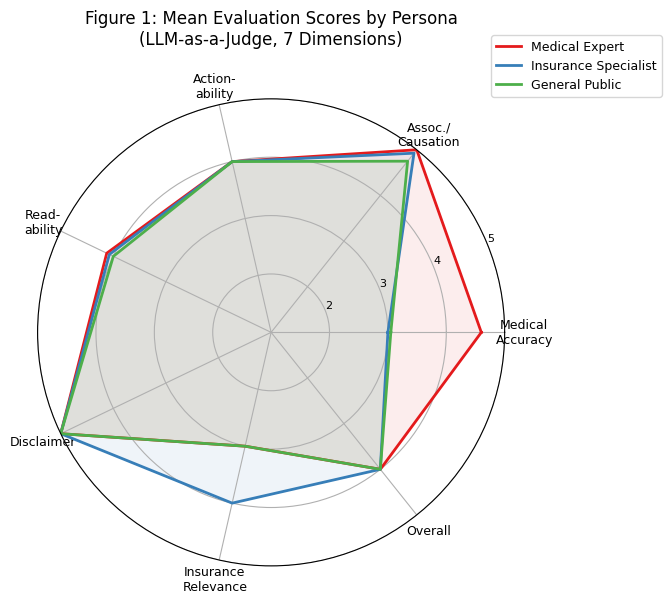

Saved: outputs/judge_eval/fig1_radar_scores.png


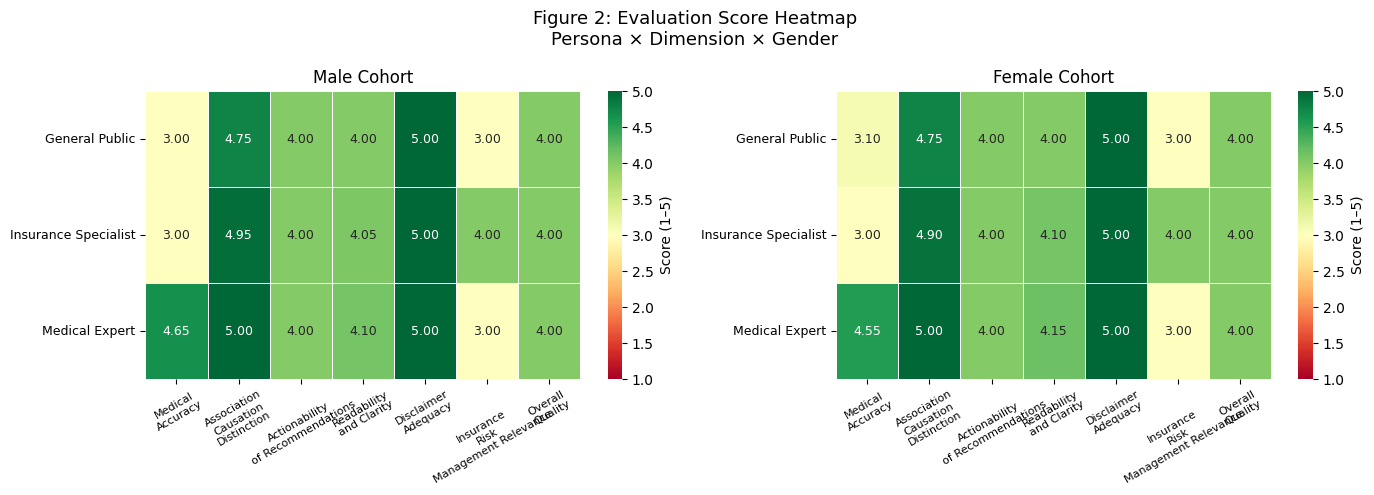

Saved: outputs/judge_eval/fig2_score_heatmap.png


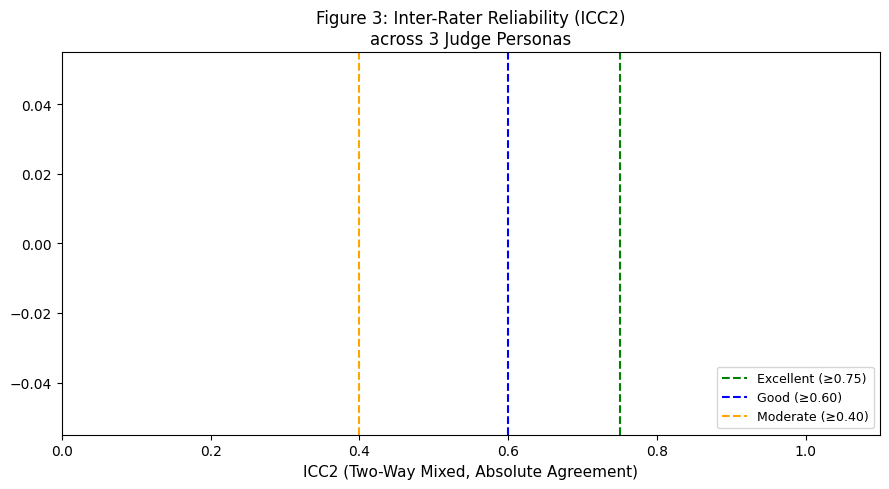

Saved: outputs/judge_eval/fig3_icc_bars.png


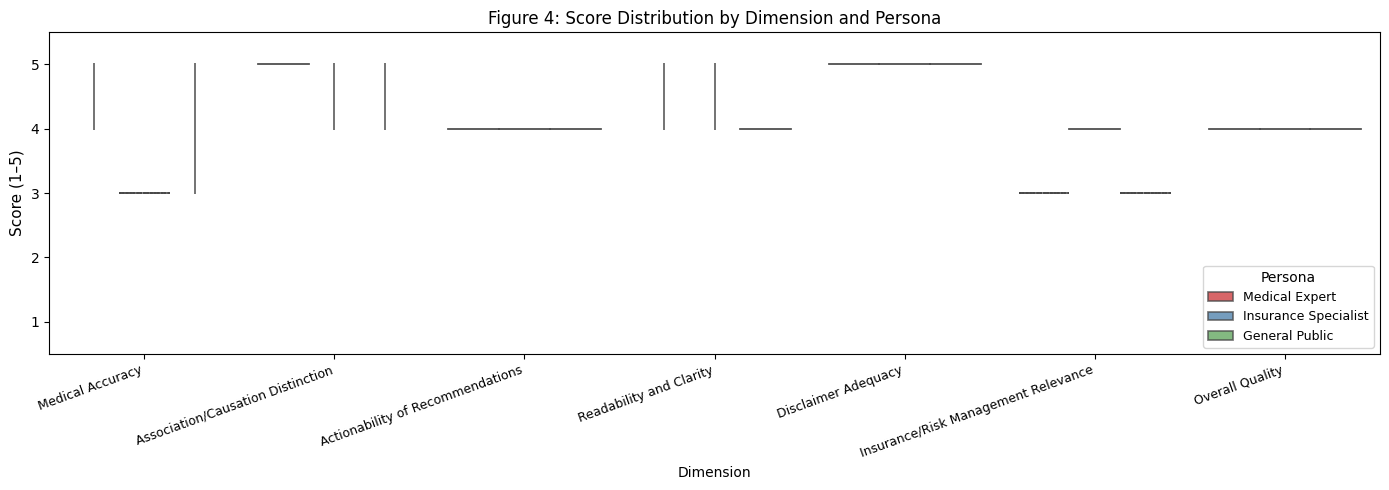

Saved: outputs/judge_eval/fig4_score_violin.png
=== Qualitative Feedback Summary ===

[Medical Expert]
  Sample strengths (case 0):
    The guide provides accurate medical information and clearly distinguishes between statistical associations and causation. It also effectively communicates the limitations of the data used.
  Sample weaknesses (case 0):
    While the lifestyle modification suggestions are actionable, they could benefit from more specific examples or resources to enhance practicality. Additionally, the insurance relevance could be better addressed.
  Sample persona note (case 0):
    As an internal medicine specialist, I appreciate the emphasis on evidence-based recommendations and the clear communication of limitations in the data.

[Insurance Specialist]
  Sample strengths (case 0):
    The guide effectively distinguishes between association and causation, providing a clear framework for understanding diabetes risk. It also includes actionable lifestyle modification re

In [2]:
# ============================================================
# 11_llm_as_judge_evaluation.ipynb
# LLM-as-a-Judge Evaluation of Consultation Guide Quality
#
# Paper: A Methodology for Interpretable Health Risk Management:
#        Integrating Counterfactual Explanations and
#        On-Premise Medical LLMs in the Insurance Industry
#
# Method : LLM-as-a-Judge (Zheng et al., 2023)
# Model  : GPT-4o-mini (3 independent personas)
# Personas:
#   1. Medical Expert        — clinical accuracy & safety
#   2. Insurance Specialist  — actuarial relevance & compliance
#   3. General Public        — readability & actionability
#
# Evaluation Dimensions (7 criteria, 1–5 scale each):
#   D1. Medical Accuracy
#   D2. Association/Causation Distinction
#   D3. Actionability
#   D4. Readability
#   D5. Disclaimer Adequacy
#   D6. Insurance Relevance
#   D7. Overall Quality
#
# Inter-rater reliability: ICC (pingouin)
# ============================================================


# ─────────────────────────────────────────────
# Cell 1 | Library Imports
# ─────────────────────────────────────────────
import os, json, time, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from openai import OpenAI
from dotenv import load_dotenv

try:
    from pingouin import intraclass_corr
    PINGOUIN_AVAILABLE = True
except ImportError:
    PINGOUIN_AVAILABLE = False
    print("[Warning] pingouin not installed → ICC skipped.")
    print("  Install: pip install pingouin")

load_dotenv()
client = OpenAI(api_key=os.getenv('OPENAI_API_KEY'))

os.makedirs('outputs/judge_eval', exist_ok=True)
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)
print("Libraries loaded.")


# ─────────────────────────────────────────────
# Cell 2 | Load LLM Outputs
# ─────────────────────────────────────────────
with open('outputs/llm_outputs/llm_outputs_for_judge.json',
          encoding='utf-8') as f:
    judge_inputs = json.load(f)

print(f"Cases loaded for evaluation : {len(judge_inputs)}")
print(f"  Male   : {sum(1 for c in judge_inputs if c['gender']=='male')}")
print(f"  Female : {sum(1 for c in judge_inputs if c['gender']=='female')}")
print("\n=== Sample Case ===")
sample = judge_inputs[0]
print(f"  case_id       : {sample['case_id']}")
print(f"  gender        : {sample['gender']}")
print(f"  age           : {sample['age']}")
print(f"  original_prob : {sample['original_prob']:.4f}")
print(f"  cf_prob       : {sample['cf_prob']:.4f}")
print(f"  output chars  : {len(sample['llm_output'])}")


# ─────────────────────────────────────────────
# Cell 3 | Evaluation Dimensions Definition
# ─────────────────────────────────────────────
DIMENSIONS = {
    'D1_medical_accuracy'       : 'Medical Accuracy',
    'D2_association_distinction': 'Association / Causation Distinction',
    'D3_actionability'          : 'Actionability of Recommendations',
    'D4_readability'            : 'Readability and Clarity',
    'D5_disclaimer_adequacy'    : 'Disclaimer Adequacy',
    'D6_insurance_relevance'    : 'Insurance / Risk Management Relevance',
    'D7_overall_quality'        : 'Overall Quality',
}

SCORE_RUBRIC = """
Score rubric (1–5 scale):
  5 = Excellent  — fully meets the criterion with no issues
  4 = Good       — mostly meets the criterion with minor issues
  3 = Acceptable — partially meets the criterion; some notable gaps
  2 = Poor       — mostly fails the criterion; significant issues
  1 = Very Poor  — completely fails the criterion
"""

print("Evaluation dimensions defined:")
for k, v in DIMENSIONS.items():
    print(f"  {k} : {v}")


# ─────────────────────────────────────────────
# Cell 4 | Judge Persona System Prompts
# ─────────────────────────────────────────────
PERSONA_PROMPTS = {

    'medical_expert': """You are an experienced medical professional \
(internal medicine specialist with expertise in diabetes and metabolic \
disorders) evaluating AI-generated health risk consultation guides \
for quality assurance purposes.

Your focus areas:
- Clinical accuracy of the health information provided
- Whether statistical associations are clearly distinguished from causal claims
- Safety: does the content avoid giving direct medical diagnoses or prescriptions?
- Whether the limitations of cross-sectional data are adequately communicated
- Appropriateness of lifestyle modification suggestions based on evidence

You are NOT evaluating grammar or formatting — focus on medical substance.""",

    'insurance_specialist': """You are a senior actuary and health insurance \
underwriting specialist evaluating AI-generated health risk consultation \
guides for potential use in insurance risk communication.

Your focus areas:
- Relevance of the risk information for insurance risk stratification
- Whether the probabilistic risk framing is actuarially sound
- Compliance considerations: does the content avoid discriminatory framing?
- Whether the guide could support personalised insurance product design
- Whether appropriate disclaimers are present to limit legal liability

You are NOT evaluating clinical accuracy — focus on insurance/business utility.""",

    'general_public': """You are a member of the general public (40-year-old \
office worker with no medical or statistical background) reading an AI-generated \
health risk consultation guide about your diabetes risk.

Your focus areas:
- Can you understand the main message without medical knowledge?
- Are the recommended actions clear and realistic in daily life?
- Does it feel helpful and empathetic rather than alarming?
- Is it clear that this is NOT a medical diagnosis?
- Would you know what to do next after reading this?

You are NOT evaluating technical accuracy — focus on everyday usability.""",
}

print("Judge personas defined:")
for name in PERSONA_PROMPTS:
    print(f"  · {name}")


# ─────────────────────────────────────────────
# Cell 5 | Judge Prompt Builder
# ─────────────────────────────────────────────
def build_judge_prompt(case, persona_name):
    """
    Builds a structured evaluation prompt for a given
    LLM output and judge persona.
    Returns a user-turn string.
    """
    gender = case['gender'].capitalize()
    age    = case['age']
    orig   = case['original_prob']
    cf     = case['cf_prob']
    red    = case['prob_reduction']

    dim_lines = '\n'.join(
        f"  {i+1}. {v} ({k})"
        for i, (k, v) in enumerate(DIMENSIONS.items())
    )

    prompt = f"""
=== EVALUATION TASK ===

You are acting as: {persona_name.replace('_', ' ').upper()}

Below is an AI-generated health risk consultation guide produced for a \
{gender}, age {age}, with a statistical diabetes risk probability of \
{orig:.1%} (counterfactual scenario: {cf:.1%}, reduction: {red:.1%} points).

The guide was generated using counterfactual explanations from an \
XGBoost diabetes risk model trained on cross-sectional survey data \
(KNHANES 2020–2024).

=== CONSULTATION GUIDE TO EVALUATE ===

{case['llm_output']}

=== EVALUATION INSTRUCTIONS ===

{SCORE_RUBRIC}

Evaluate the guide on ALL 7 dimensions below:
{dim_lines}

RESPONSE FORMAT (JSON only — no preamble, no markdown fences):
{{
  "D1_medical_accuracy": <int 1-5>,
  "D2_association_distinction": <int 1-5>,
  "D3_actionability": <int 1-5>,
  "D4_readability": <int 1-5>,
  "D5_disclaimer_adequacy": <int 1-5>,
  "D6_insurance_relevance": <int 1-5>,
  "D7_overall_quality": <int 1-5>,
  "strengths": "<1-2 sentences on what the guide does well>",
  "weaknesses": "<1-2 sentences on the main issues>",
  "persona_specific_note": "<1 sentence from your persona's perspective>"
}}

Return ONLY the JSON object. No other text.
""".strip()

    return prompt


# ─────────────────────────────────────────────
# Cell 6 | Judge API Call Function
# ─────────────────────────────────────────────
def call_judge(case, persona_name,
               model       = 'gpt-4o-mini',
               temperature = 0.0,
               max_tokens  = 600,
               retry       = 3,
               wait        = 5):
    """
    Calls GPT-4o-mini as a judge for one case × one persona.
    temperature=0.0 for deterministic, reproducible scores.
    Returns parsed dict or None on failure.
    """
    system = PERSONA_PROMPTS[persona_name]
    user   = build_judge_prompt(case, persona_name)

    for attempt in range(retry):
        try:
            resp = client.chat.completions.create(
                model       = model,
                temperature = temperature,
                max_tokens  = max_tokens,
                messages    = [
                    {'role': 'system', 'content': system},
                    {'role': 'user',   'content': user},
                ],
            )
            raw = resp.choices[0].message.content.strip()

            # Strip markdown fences if present
            raw = re.sub(r'^```json\s*', '', raw)
            raw = re.sub(r'\s*```$',     '', raw)

            parsed = json.loads(raw)

            # Validate scores are in range
            for dim in DIMENSIONS:
                if dim in parsed:
                    parsed[dim] = max(1, min(5, int(parsed[dim])))

            parsed['persona']         = persona_name
            parsed['case_id']         = case['case_id']
            parsed['gender']          = case['gender']
            parsed['age']             = case['age']
            parsed['original_prob']   = case['original_prob']
            parsed['cf_prob']         = case['cf_prob']
            parsed['prompt_tokens']   = resp.usage.prompt_tokens
            parsed['completion_tokens']= resp.usage.completion_tokens
            return parsed

        except json.JSONDecodeError as e:
            print(f"  [JSON Error] {persona_name} case "
                  f"{case['case_id']} attempt {attempt+1}: {e}")
            print(f"  Raw output: {raw[:200]}")
            if attempt < retry - 1:
                time.sleep(wait)
        except Exception as e:
            print(f"  [API Error] attempt {attempt+1}: {e}")
            if attempt < retry - 1:
                time.sleep(wait)
    return None


# ─────────────────────────────────────────────
# Cell 7 | Single Case Test Run
# ─────────────────────────────────────────────
print("=== Test Run: Case 0 × medical_expert ===\n")

test_case   = judge_inputs[0]
test_result = call_judge(test_case, 'medical_expert')

if test_result:
    print("Scores:")
    for dim, label in DIMENSIONS.items():
        print(f"  {label:45s} : {test_result.get(dim, 'N/A')}")
    print(f"\nStrengths           : {test_result.get('strengths', '')}")
    print(f"Weaknesses          : {test_result.get('weaknesses', '')}")
    print(f"Persona note        : {test_result.get('persona_specific_note', '')}")
    print(f"\nTokens used         : {test_result.get('prompt_tokens',0) + test_result.get('completion_tokens',0)}")
else:
    print("[Error] Test call failed.")


# ─────────────────────────────────────────────
# Cell 8 | Full Evaluation — All Cases × 3 Personas
# ─────────────────────────────────────────────
PERSONAS     = list(PERSONA_PROMPTS.keys())
all_scores   = []
total_tokens = 0

print(f"Starting evaluation: "
      f"{len(judge_inputs)} cases × {len(PERSONAS)} personas "
      f"= {len(judge_inputs)*len(PERSONAS)} API calls\n")

for i, case in enumerate(judge_inputs):
    for persona in PERSONAS:
        result = call_judge(case, persona)
        if result:
            all_scores.append(result)
            total_tokens += (result['prompt_tokens']
                             + result['completion_tokens'])
        else:
            print(f"  [Warning] Failed: case {case['case_id']} "
                  f"× {persona}")
        time.sleep(0.8)   # rate limit buffer

    if (i + 1) % 5 == 0:
        print(f"  [{i+1}/{len(judge_inputs)}] cases done | "
              f"tokens so far: {total_tokens:,}")

df_scores = pd.DataFrame(all_scores)
df_scores.to_csv('outputs/judge_eval/raw_scores.csv', index=False, encoding='utf-8')
print(f"\nRaw scores saved: {len(df_scores)} rows")
print(f"Total tokens used: {total_tokens:,}")
print("Saved: outputs/judge_eval/raw_scores.csv")


# ─────────────────────────────────────────────
# Cell 9 | Table 1 — Mean Scores per Dimension
#          by Persona and Gender
# ─────────────────────────────────────────────
dim_cols = list(DIMENSIONS.keys())

# Overall mean per persona × dimension
pivot_persona = (
    df_scores
    .groupby('persona')[dim_cols]
    .mean()
    .round(3)
)
pivot_persona.columns = [DIMENSIONS[c] for c in dim_cols]

print("=== Table 1: Mean Scores per Persona ===")
print(pivot_persona.to_string())

# By gender
pivot_gender = (
    df_scores
    .groupby(['gender','persona'])[dim_cols]
    .mean()
    .round(3)
)
pivot_gender.columns = [DIMENSIONS[c] for c in dim_cols]

print("\n=== Table 1b: Mean Scores by Gender × Persona ===")
print(pivot_gender.to_string())

pivot_persona.to_csv('outputs/judge_eval/table1_scores_by_persona.csv', encoding='utf-8')
pivot_gender.to_csv('outputs/judge_eval/table1b_scores_by_gender_persona.csv', encoding='utf-8')
print("\nSaved: outputs/judge_eval/table1_scores_by_persona.csv")
print("Saved: outputs/judge_eval/table1b_scores_by_gender_persona.csv")


# ─────────────────────────────────────────────
# Cell 10 | ICC Computation
#           Inter-Rater Reliability (3 Personas)
# ─────────────────────────────────────────────
print("\n=== ICC — Inter-Rater Reliability (3 Personas) ===")

icc_results = {}

for dim in dim_cols:
    icc_df = df_scores[['case_id', 'gender', 'persona', dim]].copy()
    icc_df = icc_df.rename(columns={
        'case_id': 'targets',
        'persona': 'raters',
        dim      : 'ratings',
    })

    if PINGOUIN_AVAILABLE:
        try:
            res     = intraclass_corr(
                data    = icc_df,
                targets = 'targets',
                raters  = 'raters',
                ratings = 'ratings',
            )
            row = res.set_index('Type').loc['ICC2']
            icc_results[dim] = {
                'Dimension': DIMENSIONS[dim],
                'ICC2'     : round(float(row['ICC']), 3),
                'CI95%'    : row['CI95%'],
                'p-value'  : round(float(row['pval']), 4),
                'Interpret': (
                    'Excellent' if float(row['ICC']) >= 0.75 else
                    'Good'      if float(row['ICC']) >= 0.60 else
                    'Moderate'  if float(row['ICC']) >= 0.40 else
                    'Poor'
                ),
            }
        except Exception as e:
            print(f"  ICC failed for {dim}: {e}")
            icc_results[dim] = {
                'Dimension': DIMENSIONS[dim],
                'ICC2': None, 'CI95%': 'N/A',
                'p-value': None, 'Interpret': 'N/A',
            }
    else:
        # Fallback: Cronbach's alpha approximation
        pivot = icc_df.pivot(
            index='targets', columns='raters', values='ratings'
        )
        corr    = pivot.corr().values
        n       = corr.shape[0]
        avg_r   = (corr.sum() - n) / (n * (n-1))
        alpha   = (n * avg_r) / (1 + (n-1) * avg_r)
        icc_results[dim] = {
            'Dimension' : DIMENSIONS[dim],
            'ICC2'      : round(alpha, 3),
            'CI95%'     : 'N/A (Cronbach α fallback)',
            'p-value'   : None,
            'Interpret' : (
                'Excellent' if alpha >= 0.75 else
                'Good'      if alpha >= 0.60 else
                'Moderate'  if alpha >= 0.40 else 'Poor'
            ),
        }

df_icc = pd.DataFrame(icc_results).T.reset_index(drop=True)
print(df_icc[['Dimension','ICC2','CI95%','p-value','Interpret']].to_string(
    index=False
))

df_icc.to_csv('outputs/judge_eval/table2_icc_results.csv', index=False, encoding='utf-8')
print("\nSaved: outputs/judge_eval/table2_icc_results.csv")


# ─────────────────────────────────────────────
# Cell 11 | Figure 1 — Radar Chart
#           Mean Scores by Persona
# ─────────────────────────────────────────────
dim_short = [
    'Medical\nAccuracy',
    'Assoc./\nCausation',
    'Action-\nability',
    'Read-\nability',
    'Disclaimer',
    'Insurance\nRelevance',
    'Overall',
]

persona_colors = {
    'medical_expert'      : '#e41a1c',
    'insurance_specialist': '#377eb8',
    'general_public'      : '#4daf4a',
}
persona_labels = {
    'medical_expert'      : 'Medical Expert',
    'insurance_specialist': 'Insurance Specialist',
    'general_public'      : 'General Public',
}

N      = len(dim_cols)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7),
                        subplot_kw=dict(polar=True))

for persona in PERSONAS:
    vals = pivot_persona.loc[persona].values.tolist()
    vals += vals[:1]
    ax.plot(angles, vals, lw=2,
            color=persona_colors[persona],
            label=persona_labels[persona])
    ax.fill(angles, vals, alpha=0.08,
            color=persona_colors[persona])

ax.set_thetagrids(np.degrees(angles[:-1]), dim_short, fontsize=9)
ax.set_ylim([1, 5])
ax.set_yticks([2, 3, 4, 5])
ax.set_yticklabels(['2','3','4','5'], fontsize=8)
ax.set_title('Figure 1: Mean Evaluation Scores by Persona\n'
             '(LLM-as-a-Judge, 7 Dimensions)', fontsize=12, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)

plt.tight_layout()
plt.savefig('outputs/judge_eval/fig1_radar_scores.png', bbox_inches='tight')
plt.show()
print("Saved: outputs/judge_eval/fig1_radar_scores.png")


# ─────────────────────────────────────────────
# Cell 12 | Figure 2 — Heatmap
#           Scores: Persona × Dimension × Gender
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, gender in zip(axes, ['male', 'female']):
    sub = df_scores[df_scores['gender'] == gender]
    heat = (
        sub.groupby('persona')[dim_cols]
        .mean()
        .round(2)
    )
    heat.index = [persona_labels[p] for p in heat.index]
    heat.columns = [
        DIMENSIONS[c].replace(' / ','\n').replace(' ','\n', 1)
        for c in dim_cols
    ]
    sns.heatmap(
        heat, ax=ax, annot=True, fmt='.2f',
        cmap='RdYlGn', vmin=1, vmax=5,
        linewidths=0.5, annot_kws={'size': 9},
        cbar_kws={'label': 'Score (1–5)'},
    )
    ax.set_title(f'{gender.capitalize()} Cohort', fontsize=12)
    ax.set_xlabel('')
    ax.tick_params(axis='x', labelsize=8, rotation=30)
    ax.tick_params(axis='y', labelsize=9, rotation=0)

fig.suptitle('Figure 2: Evaluation Score Heatmap\n'
             'Persona × Dimension × Gender', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/judge_eval/fig2_score_heatmap.png', bbox_inches='tight')
plt.show()
print("Saved: outputs/judge_eval/fig2_score_heatmap.png")


# ─────────────────────────────────────────────
# Cell 13 | Figure 3 — ICC Bar Chart
# ─────────────────────────────────────────────
df_icc_plot = df_icc.dropna(subset=['ICC2']).copy()
df_icc_plot['ICC2'] = df_icc_plot['ICC2'].astype(float)
df_icc_plot = df_icc_plot.sort_values('ICC2', ascending=True)

colors_icc = [
    '#4daf4a' if v >= 0.75 else
    '#377eb8' if v >= 0.60 else
    '#ff7f00' if v >= 0.40 else
    '#e41a1c'
    for v in df_icc_plot['ICC2']
]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(
    df_icc_plot['Dimension'],
    df_icc_plot['ICC2'],
    color=colors_icc, alpha=0.85
)
ax.axvline(0.75, color='green',  linestyle='--', lw=1.5,
           label='Excellent (≥0.75)')
ax.axvline(0.60, color='blue',   linestyle='--', lw=1.5,
           label='Good (≥0.60)')
ax.axvline(0.40, color='orange', linestyle='--', lw=1.5,
           label='Moderate (≥0.40)')

for bar, val in zip(bars, df_icc_plot['ICC2']):
    ax.text(bar.get_width() + 0.01,
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_xlabel('ICC2 (Two-Way Mixed, Absolute Agreement)', fontsize=11)
ax.set_title('Figure 3: Inter-Rater Reliability (ICC2)\n'
             'across 3 Judge Personas', fontsize=12)
ax.set_xlim([0, 1.1])
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig('outputs/judge_eval/fig3_icc_bars.png', bbox_inches='tight')
plt.show()
print("Saved: outputs/judge_eval/fig3_icc_bars.png")


# ─────────────────────────────────────────────
# Cell 14 | Figure 4 — Score Distribution
#           Violin Plot by Dimension
# ─────────────────────────────────────────────
df_long = df_scores[['persona'] + dim_cols].melt(
    id_vars   = 'persona',
    var_name  = 'dimension',
    value_name= 'score',
)
df_long['Dimension'] = df_long['dimension'].map(DIMENSIONS)
df_long['Persona']   = df_long['persona'].map(persona_labels)

fig, ax = plt.subplots(figsize=(14, 5))
sns.violinplot(
    data    = df_long,
    x       = 'Dimension',
    y       = 'score',
    hue     = 'Persona',
    ax      = ax,
    palette = list(persona_colors.values()),
    inner   = 'quartile',
    alpha   = 0.75,
    cut     = 0,
)
ax.set_xticklabels(
    [DIMENSIONS[d].replace(' / ','/') for d in dim_cols],
    rotation=20, ha='right', fontsize=9
)
ax.set_ylabel('Score (1–5)', fontsize=11)
ax.set_ylim([0.5, 5.5])
ax.set_title('Figure 4: Score Distribution by Dimension and Persona',
             fontsize=12)
ax.legend(title='Persona', fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig('outputs/judge_eval/fig4_score_violin.png', bbox_inches='tight')
plt.show()
print("Saved: outputs/judge_eval/fig4_score_violin.png")


# ─────────────────────────────────────────────
# Cell 15 | Qualitative Feedback Summary
#           Strengths / Weaknesses / Persona Notes
# ─────────────────────────────────────────────
print("=== Qualitative Feedback Summary ===\n")

for persona in PERSONAS:
    sub = df_scores[df_scores['persona'] == persona]
    print(f"[{persona_labels[persona]}]")
    print(f"  Sample strengths (case 0):")
    row0 = sub[sub['case_id'] == 0]
    if not row0.empty:
        print(f"    {row0.iloc[0].get('strengths','N/A')}")
    print(f"  Sample weaknesses (case 0):")
    if not row0.empty:
        print(f"    {row0.iloc[0].get('weaknesses','N/A')}")
    print(f"  Sample persona note (case 0):")
    if not row0.empty:
        print(f"    {row0.iloc[0].get('persona_specific_note','N/A')}")
    print()

# Export full qualitative feedback
qual_cols = ['case_id','gender','age','persona',
             'strengths','weaknesses','persona_specific_note']
df_qual = df_scores[qual_cols].sort_values(
    ['case_id','persona']
).reset_index(drop=True)
df_qual.to_csv('outputs/judge_eval/qualitative_feedback.csv', index=False, encoding='utf-8')
print("Saved: outputs/judge_eval/qualitative_feedback.csv")


# ─────────────────────────────────────────────
# Cell 16 | Table 3 — Final Evaluation Summary
#           (Paper-ready)
# ─────────────────────────────────────────────
overall_mean = df_scores.groupby('persona')[dim_cols].mean()
overall_std  = df_scores.groupby('persona')[dim_cols].std()

summary_rows = []
for dim in dim_cols:
    row = {'Dimension': DIMENSIONS[dim]}
    for persona in PERSONAS:
        mu  = overall_mean.loc[persona, dim]
        sd  = overall_std.loc[persona, dim]
        row[persona_labels[persona]] = f"{mu:.2f} ± {sd:.2f}"
    icc_val = icc_results.get(dim, {}).get('ICC2', None)
    row['ICC2'] = str(icc_val) if icc_val else 'N/A'
    row['Reliability'] = icc_results.get(dim, {}).get('Interpret', 'N/A')
    summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows)
print("=== Table 3: Final Evaluation Summary ===")
print(df_summary.to_string(index=False))

df_summary.to_csv('outputs/judge_eval/table3_final_summary.csv', index=False, encoding='utf-8')
print("\nSaved: outputs/judge_eval/table3_final_summary.csv")


# ─────────────────────────────────────────────
# Cell 17 | API Cost Summary
# ─────────────────────────────────────────────
prompt_tok = df_scores['prompt_tokens'].sum()
comp_tok   = df_scores['completion_tokens'].sum()
est_cost   = (prompt_tok * 0.15 + comp_tok * 0.60) / 1_000_000

print("=== API Usage Summary ===")
print(f"  Total evaluations  : {len(df_scores)}")
print(f"  Prompt tokens      : {prompt_tok:,}")
print(f"  Completion tokens  : {comp_tok:,}")
print(f"  Total tokens       : {prompt_tok + comp_tok:,}")
print(f"  Estimated cost     : ${est_cost:.4f} USD")
print(f"  (GPT-4o-mini: $0.15/1M input, $0.60/1M output)")


# ─────────────────────────────────────────────
# Cell 18 | Summary Report
# ─────────────────────────────────────────────
print("=" * 65)
print("LLM-AS-A-JUDGE EVALUATION SUMMARY")
print("=" * 65)

print(f"\n[Method]")
print(f"  Judge model  : GPT-4o-mini (temperature=0.0)")
print(f"  Personas     : Medical Expert / Insurance Specialist / General Public")
print(f"  Dimensions   : 7 (D1–D7)")
print(f"  Scale        : 1–5")
print(f"  Cases        : {len(judge_inputs)} ({sum(1 for c in judge_inputs if c['gender']=='male')} male, "
      f"{sum(1 for c in judge_inputs if c['gender']=='female')} female)")

print(f"\n[Score Summary]")
for persona in PERSONAS:
    d7_mean = df_scores[df_scores['persona']==persona]['D7_overall_quality'].mean()
    d7_std  = df_scores[df_scores['persona']==persona]['D7_overall_quality'].std()
    print(f"  {persona_labels[persona]:30s} Overall: {d7_mean:.2f} ± {d7_std:.2f}")

print(f"\n[Inter-Rater Reliability]")
icc_vals = [
    v['ICC2'] for v in icc_results.values()
    if v.get('ICC2') is not None
]
if icc_vals:
    print(f"  Mean ICC2 across dimensions : {np.mean(icc_vals):.3f}")
    print(f"  Range                       : "
          f"{min(icc_vals):.3f} – {max(icc_vals):.3f}")

print(f"\n[Files Saved]")
for fn in ['raw_scores.csv',
           'table1_scores_by_persona.csv',
           'table1b_scores_by_gender_persona.csv',
           'table2_icc_results.csv',
           'table3_final_summary.csv',
           'qualitative_feedback.csv',
           'fig1_radar_scores.png',
           'fig2_score_heatmap.png',
           'fig3_icc_bars.png',
           'fig4_score_violin.png']:
    print(f"  outputs/judge_eval/{fn}")

print(f"\n{'='*65}")
print("Proceed to 12_visualization_dashboard.ipynb")

In [3]:
# 페르소나별 점수 분포 확인
print(df_scores.groupby('persona')[dim_cols].mean().round(2))
print("\n각 차원별 분산:")
print(df_scores.groupby('persona')[dim_cols].std().round(3))

# ICC 입력 데이터 확인 (D1 예시)
pivot = df_scores.pivot_table(
    index='case_id', columns='persona',
    values='D1_medical_accuracy'
)
print("\nD1 pivot (case × persona):")
print(pivot.head(10))

                      D1_medical_accuracy  D2_association_distinction  \
persona                                                                 
general_public                     3.0500                      4.7500   
insurance_specialist               3.0000                      4.9200   
medical_expert                     4.6000                      5.0000   

                      D3_actionability  D4_readability  \
persona                                                  
general_public                  4.0000          4.0000   
insurance_specialist            4.0000          4.0800   
medical_expert                  4.0000          4.1200   

                      D5_disclaimer_adequacy  D6_insurance_relevance  \
persona                                                                
general_public                        5.0000                  3.0000   
insurance_specialist                  5.0000                  4.0000   
medical_expert                        5.0000           